# Assignment 9: Applying a Variational Autoencoder to Compression and Denoising

**Objective:** To investigate two practical uses of a Variational Autoencoder (VAE)—data compression and image denoising—using the VAE developed in Assignment 8 with the MNIST dataset, while examining how different latent dimensions influence the outcomes.

## Step 1: Library Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

## Step 2: Parameters and Loading the MNIST Dataset

The parameters remain consistent with Assignment 8: a batch size of 128, 20 training epochs, and a learning rate of 0.001. A noise level is introduced for the denoising experiment. As before, the MNIST dataset is loaded with pixel values normalized to the range [0, 1].

In [2]:
# Basic parameters (same as Assignment 8)
BATCH_SIZE = 128
EPOCHS = 20
LEARNING_RATE = 0.001

# Extra settings for this assignment
NOISE_STD = 0.3          # standard deviation of the Gaussian noise used in the denoising part
NUM_TEST_IMAGES = 10     # number of test images used in Parts B and C

# Fixing the seed so the results can be repeated
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor()      # pixel values stay in [0, 1], same as Assignment 8
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Training samples : {len(train_dataset)}")
print(f"Testing samples  : {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 462kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.14MB/s]

Training samples : 60000
Testing samples  : 10000


## Step 3: VAE with Adjustable Latent Dimension and Loss Function

The VAE architecture remains the same as in Assignment 8 (784 → 256 → 64 → latent → 64 → 256 → 784). The difference is that the latent size is now controlled by the `latent_dim` setting, allowing the same class to be used with 2, 16, and 32 dimensions in Part D. The loss function is unchanged from Assignment 8.

In [4]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()

        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )

        # Mean and log variance layers
        self.fc_mu      = nn.Linear(64, latent_dim)
        self.fc_log_var = nn.Linear(64, latent_dim)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        x = x.view(-1, 784)

        # Encode
        h       = self.encoder(x)
        mu      = self.fc_mu(h)
        log_var = self.fc_log_var(h)

        # Sample from the distribution
        z = self.reparameterize(mu, log_var)

        # Decode
        output = self.decoder(z)

        return output, mu, log_var

In [5]:
def vae_loss(output, target, mu, log_var):

    # Reconstruction loss (MSE)
    target = target.view(-1, 784)
    reconstruction_loss = nn.functional.mse_loss(output, target, reduction='sum')

    # KL Divergence loss
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())

    # Total loss
    total_loss = reconstruction_loss + kl_loss

    return total_loss, reconstruction_loss, kl_loss


# Checking the 2-dimensional VAE (the one from Assignment 8)
vae_2 = VAE(latent_dim=2).to(device)
print(vae_2)

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
  )
  (fc_mu): Linear(in_features=64, out_features=2, bias=True)
  (fc_log_var): Linear(in_features=64, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


## Step 4: Training the 2-Dimensional VAE

The training loop from Assignment 8 is placed inside a function so that it can also be reused later to train the 16- and 32-dimensional models in Part D. The 2-dimensional VAE is trained first using the same model and settings as Assignment 8: 20 epochs with the existing parameters.

In [6]:
def train_vae(model, epochs=EPOCHS, lr=LEARNING_RATE):

    optimizer = optim.Adam(model.parameters(), lr=lr)

    recon_losses = []
    kl_losses    = []
    total_losses = []

    for epoch in range(1, epochs + 1):

        total_loss_epoch = 0
        recon_loss_epoch = 0
        kl_loss_epoch    = 0

        for images, _ in train_loader:
            images = images.to(device)

            output, mu, log_var = model(images)

            total_loss, recon_loss, kl_loss = vae_loss(output, images, mu, log_var)

            optimizer.zero_grad()
            total_loss.backward()
            optimizer.step()

            total_loss_epoch += total_loss.item()
            recon_loss_epoch += recon_loss.item()
            kl_loss_epoch    += kl_loss.item()

        avg_total = total_loss_epoch / len(train_loader)
        avg_recon = recon_loss_epoch / len(train_loader)
        avg_kl    = kl_loss_epoch    / len(train_loader)

        total_losses.append(avg_total)
        recon_losses.append(avg_recon)
        kl_losses.append(avg_kl)

        print(f"Epoch [{epoch}/{epochs}]  Total Loss: {avg_total:.2f}  Reconstruction Loss: {avg_recon:.2f}  KL Loss: {avg_kl:.2f}")

    return total_losses, recon_losses, kl_losses


# Train the 2-dimensional VAE (the Assignment 8 model)
total_2, recon_2, kl_2 = train_vae(vae_2)

Epoch [1/20]  Total Loss: 6583.94  Reconstruction Loss: 6317.71  KL Loss: 266.23
Epoch [2/20]  Total Loss: 5457.20  Reconstruction Loss: 5039.16  KL Loss: 418.03
Epoch [3/20]  Total Loss: 5210.78  Reconstruction Loss: 4736.31  KL Loss: 474.47
Epoch [4/20]  Total Loss: 5087.10  Reconstruction Loss: 4582.46  KL Loss: 504.63
Epoch [5/20]  Total Loss: 4994.15  Reconstruction Loss: 4466.59  KL Loss: 527.56
Epoch [6/20]  Total Loss: 4916.13  Reconstruction Loss: 4370.15  KL Loss: 545.98
Epoch [7/20]  Total Loss: 4847.05  Reconstruction Loss: 4284.17  KL Loss: 562.88
Epoch [8/20]  Total Loss: 4791.87  Reconstruction Loss: 4216.29  KL Loss: 575.58
Epoch [9/20]  Total Loss: 4747.87  Reconstruction Loss: 4162.16  KL Loss: 585.71
Epoch [10/20]  Total Loss: 4712.18  Reconstruction Loss: 4116.64  KL Loss: 595.54
Epoch [11/20]  Total Loss: 4678.31  Reconstruction Loss: 4077.30  KL Loss: 601.01
Epoch [12/20]  Total Loss: 4655.09  Reconstruction Loss: 4045.38  KL Loss: 609.72
Epoch [13/20]  Total Loss

## Plotting the Training Loss of the 2-Dimensional VAE

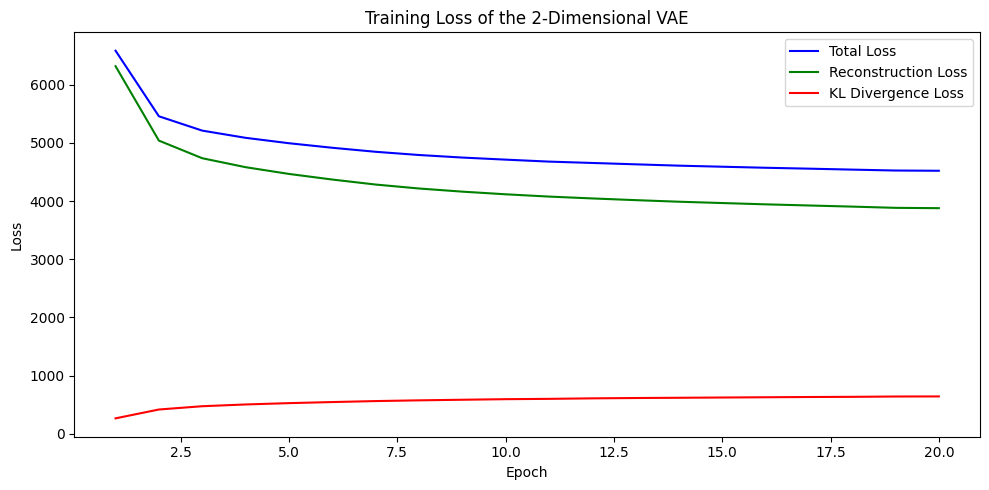

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), total_2, label='Total Loss',          color='blue')
plt.plot(range(1, EPOCHS+1), recon_2, label='Reconstruction Loss', color='green')
plt.plot(range(1, EPOCHS+1), kl_2,    label='KL Divergence Loss',  color='red')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss of the 2-Dimensional VAE')
plt.legend()
plt.tight_layout()
plt.show()

## Step 5: Part A - Compression

An original MNIST image contains 784 values (28 × 28 pixels). The VAE encoder reduces this information to a latent vector. The compression ratio is obtained by comparing the number of values in the original image with the number of values in its latent representation.

**Note:** The encoder produces two vectors: the mean (mu) and the log variance. For a compressed representation, only the mean is required because the decoder can receive the mean directly. Therefore, the latent representation size is considered equal to the latent dimension.

In [8]:
ORIGINAL_SIZE = 784      # 28 x 28 pixel values

def compression_ratio(latent_dim):
    return ORIGINAL_SIZE / latent_dim

latent_dim = 2
print(f"Original image size     : {ORIGINAL_SIZE} values")
print(f"Latent representation   : {latent_dim} values")
print(f"Compression ratio       : {ORIGINAL_SIZE} / {latent_dim} = {compression_ratio(latent_dim):.0f} : 1")

# Same comparison in bits (MNIST pixels are stored as 8-bit numbers, the latent values are 32-bit floats)
original_bits = ORIGINAL_SIZE * 8
latent_bits   = latent_dim * 32
print(f"\nIn bits: {original_bits} bits vs {latent_bits} bits = {original_bits / latent_bits:.0f} : 1")

Original image size     : 784 values
Latent representation   : 2 values
Compression ratio       : 784 / 2 = 392 : 1

In bits: 6272 bits vs 64 bits = 98 : 1


A ratio of 392 : 1 refers to the number of values rather than the actual storage size. Since pixels are stored as 8-bit numbers while the latent values are 32-bit floats, the reduction in bits is smaller (98 : 1). This is lossy rather than lossless compression because the decoder reconstructs only an approximation of the original image. The reconstruction quality is evaluated in Part B.

## Step 6: Part B - Reconstruction

Ten test images are converted into latent representations and then decoded back into images. Each reconstructed image is compared with its original, and the Mean Squared Error (MSE) is calculated. The mean (mu) is used as the latent code, which means the same input image produces the same reconstruction.

In [9]:
def encode(model, images):
    # returns the latent code (the mean mu) of the images
    model.eval()
    with torch.no_grad():
        h  = model.encoder(images.view(-1, 784))
        mu = model.fc_mu(h)
    return mu

def decode(model, z):
    # returns the images rebuilt from the latent codes
    model.eval()
    with torch.no_grad():
        return model.decoder(z)

# the first 10 test images (the same ones used in Assignment 8, Step 11)
test_images, test_labels = next(iter(test_loader))
sample_images = test_images[:NUM_TEST_IMAGES].to(device)
sample_labels = test_labels[:NUM_TEST_IMAGES]

# 1. Encode  2. Decode
latent_codes  = encode(vae_2, sample_images)
reconstructed = decode(vae_2, latent_codes)

# 4. MSE for each image (average of the squared pixel differences over the 784 pixels)
original_flat = sample_images.view(-1, 784)
mse_per_image = ((reconstructed - original_flat) ** 2).mean(dim=1)

print("Image  Digit  Latent code (2 values)      MSE")
print("-" * 50)
for i in range(NUM_TEST_IMAGES):
    z = latent_codes[i].cpu().numpy()
    print(f"{i+1:>5}  {sample_labels[i].item():>5}  [{z[0]:>7.3f}, {z[1]:>7.3f}]      {mse_per_image[i].item():.4f}")

print("-" * 50)
print(f"Average MSE over the 10 images: {mse_per_image.mean().item():.4f}")

Image  Digit  Latent code (2 values)      MSE
--------------------------------------------------
    1      7  [ -1.439,  -0.694]      0.0180
    2      2  [  0.924,   0.361]      0.0698
    3      1  [  0.171,  -1.874]      0.0084
    4      0  [ -0.333,   1.378]      0.0361
    5      4  [ -1.045,   0.479]      0.0259
    6      1  [  0.193,  -1.573]      0.0064
    7      4  [ -0.473,  -0.201]      0.0561
    8      9  [ -1.340,   0.196]      0.0567
    9      5  [ -0.637,   0.097]      0.0886
   10      9  [ -0.432,  -0.568]      0.0295
--------------------------------------------------
Average MSE over the 10 images: 0.0396


A comparison of the original images (top row) and their reconstructed versions (bottom row). The MSE for each image is displayed above its corresponding reconstruction.

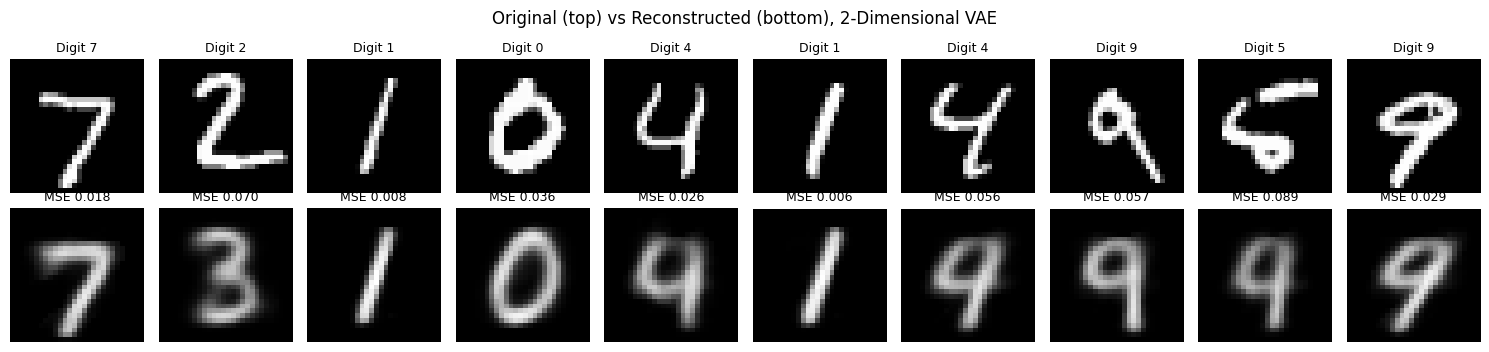

In [10]:
originals = sample_images.cpu().view(-1, 28, 28).numpy()
rebuilt   = reconstructed.cpu().view(-1, 28, 28).numpy()

plt.figure(figsize=(15, 3.6))
for i in range(NUM_TEST_IMAGES):

    # Original images - top row
    plt.subplot(2, NUM_TEST_IMAGES, i + 1)
    plt.imshow(originals[i], cmap='gray', vmin=0, vmax=1)
    plt.title(f'Digit {sample_labels[i].item()}', fontsize=9)
    plt.axis('off')

    # Reconstructed images - bottom row
    plt.subplot(2, NUM_TEST_IMAGES, i + 1 + NUM_TEST_IMAGES)
    plt.imshow(rebuilt[i], cmap='gray', vmin=0, vmax=1)
    plt.title(f'MSE {mse_per_image[i].item():.3f}', fontsize=9)
    plt.axis('off')

plt.suptitle('Original (top) vs Reconstructed (bottom), 2-Dimensional VAE')
plt.tight_layout()
plt.show()

The ten selected images represent only a small sample. For a more dependable reconstruction-error value in the results table, the MSE is also computed across all 10,000 MNIST test images.

In [11]:
def test_set_mse(model):
    # average MSE per pixel over the whole test set, using the mean (mu) as the latent code
    model.eval()
    total_error = 0.0
    count = 0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            flat   = images.view(-1, 784)
            mu     = model.fc_mu(model.encoder(flat))
            recon  = model.decoder(mu)
            total_error += ((recon - flat) ** 2).sum().item()
            count += flat.numel()
    return total_error / count

mse_full_2 = test_set_mse(vae_2)
print(f"MSE over all 10,000 test images (2-dimensional VAE): {mse_full_2:.4f}")

MSE over all 10,000 test images (2-dimensional VAE): 0.0378


## Step 7: Part C - Denoising

Random Gaussian noise is introduced into the same 10 test images. These noisy images are processed through the trained 2-dimensional VAE by encoding and decoding them, after which the clean image, noisy input, and denoised result are compared. The noise has a standard deviation of 0.3, and pixel values are clipped back to the [0, 1] range.

In [12]:
def add_noise(images, std=NOISE_STD, seed=0):
    # adds Gaussian noise with a fixed seed, so the same noise can be reused for every model
    g = torch.Generator(device=images.device)
    g.manual_seed(seed)
    noise = torch.randn(images.shape, generator=g, device=images.device) * std
    return torch.clamp(images + noise, 0.0, 1.0)

# noisy version of the same 10 test images
noisy_sample = add_noise(sample_images)

# pass the noisy images through the VAE (encode, then decode)
noisy_codes = encode(vae_2, noisy_sample)
denoised    = decode(vae_2, noisy_codes)

# errors measured against the CLEAN images
clean_flat     = sample_images.view(-1, 784)
mse_noisy      = ((noisy_sample.view(-1, 784) - clean_flat) ** 2).mean(dim=1)
mse_denoised   = ((denoised - clean_flat) ** 2).mean(dim=1)

print("Image  Digit  Noisy vs clean  Denoised vs clean  Clean recon. vs clean")
print("-" * 70)
for i in range(NUM_TEST_IMAGES):
    print(f"{i+1:>5}  {sample_labels[i].item():>5}  {mse_noisy[i].item():>13.4f}  {mse_denoised[i].item():>16.4f}  {mse_per_image[i].item():>20.4f}")

print("-" * 70)
print(f"Average  {'':>5}  {mse_noisy.mean().item():>13.4f}  {mse_denoised.mean().item():>16.4f}  {mse_per_image.mean().item():>20.4f}")

Image  Digit  Noisy vs clean  Denoised vs clean  Clean recon. vs clean
----------------------------------------------------------------------
    1      7         0.0415            0.1156                0.0180
    2      2         0.0505            0.1035                0.0698
    3      1         0.0399            0.0533                0.0084
    4      0         0.0465            0.0369                0.0361
    5      4         0.0457            0.0485                0.0259
    6      1         0.0485            0.0625                0.0064
    7      4         0.0466            0.0857                0.0561
    8      9         0.0458            0.0758                0.0567
    9      5         0.0481            0.1133                0.0886
   10      9         0.0458            0.0777                0.0295
----------------------------------------------------------------------
Average                0.0459            0.0773                0.0396


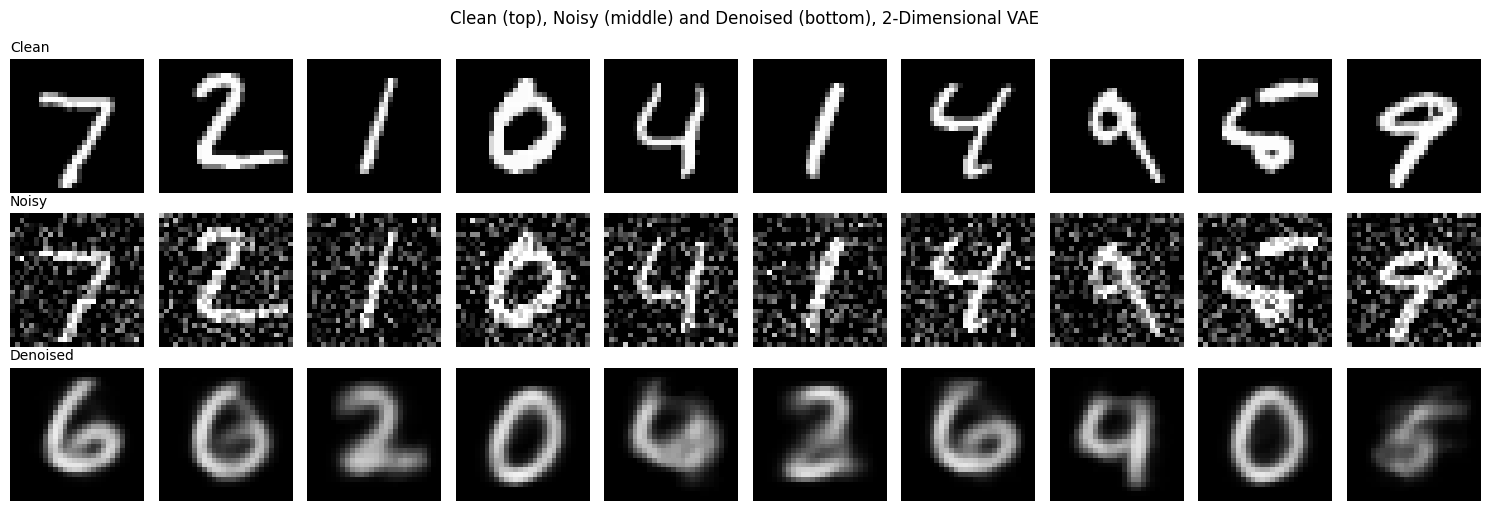

In [13]:
clean_imgs    = sample_images.cpu().view(-1, 28, 28).numpy()
noisy_imgs    = noisy_sample.cpu().view(-1, 28, 28).numpy()
denoised_imgs = denoised.cpu().view(-1, 28, 28).numpy()

rows = [(clean_imgs, 'Clean'), (noisy_imgs, 'Noisy'), (denoised_imgs, 'Denoised')]

plt.figure(figsize=(15, 5.2))
for r, (imgs, name) in enumerate(rows):
    for i in range(NUM_TEST_IMAGES):
        plt.subplot(3, NUM_TEST_IMAGES, r * NUM_TEST_IMAGES + i + 1)
        plt.imshow(imgs[i], cmap='gray', vmin=0, vmax=1)
        plt.axis('off')
        if i == 0:
            plt.title(name, fontsize=10, loc='left')

plt.suptitle('Clean (top), Noisy (middle) and Denoised (bottom), 2-Dimensional VAE')
plt.tight_layout()
plt.show()

The same evaluation is performed across all 10,000 test images. Identical noise is used for every model to make the comparisons in Part D fair.

In [14]:
def test_set_denoise_mse(model, std=NOISE_STD):
    # average MSE per pixel over the whole test set, measured against the clean images
    model.eval()
    g = torch.Generator(device=device)
    g.manual_seed(123)

    err_noisy = 0.0
    err_denoised = 0.0
    count = 0
    with torch.no_grad():
        for images, _ in test_loader:
            flat  = images.to(device).view(-1, 784)
            noisy = torch.clamp(flat + torch.randn(flat.shape, generator=g, device=device) * std, 0.0, 1.0)
            recon = model.decoder(model.fc_mu(model.encoder(noisy)))
            err_noisy    += ((noisy - flat) ** 2).sum().item()
            err_denoised += ((recon - flat) ** 2).sum().item()
            count += flat.numel()
    return err_noisy / count, err_denoised / count

noisy_mse_full, denoised_mse_full_2 = test_set_denoise_mse(vae_2)
print(f"Noisy image vs clean image    : {noisy_mse_full:.4f}")
print(f"Denoised output vs clean image: {denoised_mse_full_2:.4f}")

Noisy image vs clean image    : 0.0467
Denoised output vs clean image: 0.0670


## Step 8: Part D - Varying the Latent Dimension

The latent space is expanded from 2 dimensions to 16 and 32 dimensions. The architecture, loss function, number of epochs, and learning rate remain identical to those used for the 2-dimensional VAE, making latent size the only changed factor. Each model is trained for 20 epochs.

In [15]:
# 16-dimensional VAE
torch.manual_seed(42)
vae_16 = VAE(latent_dim=16).to(device)
total_16, recon_16, kl_16 = train_vae(vae_16)

Epoch [1/20]  Total Loss: 6727.53  Reconstruction Loss: 6456.53  KL Loss: 271.00
Epoch [2/20]  Total Loss: 5046.96  Reconstruction Loss: 4278.54  KL Loss: 768.42
Epoch [3/20]  Total Loss: 4518.03  Reconstruction Loss: 3582.53  KL Loss: 935.50
Epoch [4/20]  Total Loss: 4309.75  Reconstruction Loss: 3294.68  KL Loss: 1015.06
Epoch [5/20]  Total Loss: 4191.23  Reconstruction Loss: 3131.73  KL Loss: 1059.49
Epoch [6/20]  Total Loss: 4103.84  Reconstruction Loss: 3006.94  KL Loss: 1096.90
Epoch [7/20]  Total Loss: 4032.74  Reconstruction Loss: 2904.12  KL Loss: 1128.62
Epoch [8/20]  Total Loss: 3974.66  Reconstruction Loss: 2824.66  KL Loss: 1150.00
Epoch [9/20]  Total Loss: 3934.57  Reconstruction Loss: 2764.31  KL Loss: 1170.26
Epoch [10/20]  Total Loss: 3896.96  Reconstruction Loss: 2713.34  KL Loss: 1183.62
Epoch [11/20]  Total Loss: 3865.27  Reconstruction Loss: 2668.49  KL Loss: 1196.78
Epoch [12/20]  Total Loss: 3840.48  Reconstruction Loss: 2630.32  KL Loss: 1210.16
Epoch [13/20]  T

In [16]:
# 32-dimensional VAE
torch.manual_seed(42)
vae_32 = VAE(latent_dim=32).to(device)
total_32, recon_32, kl_32 = train_vae(vae_32)

Epoch [1/20]  Total Loss: 6748.20  Reconstruction Loss: 6472.88  KL Loss: 275.31
Epoch [2/20]  Total Loss: 5271.06  Reconstruction Loss: 4487.71  KL Loss: 783.35
Epoch [3/20]  Total Loss: 4677.26  Reconstruction Loss: 3726.37  KL Loss: 950.90
Epoch [4/20]  Total Loss: 4367.16  Reconstruction Loss: 3319.00  KL Loss: 1048.15
Epoch [5/20]  Total Loss: 4201.39  Reconstruction Loss: 3088.99  KL Loss: 1112.40
Epoch [6/20]  Total Loss: 4091.43  Reconstruction Loss: 2933.33  KL Loss: 1158.10
Epoch [7/20]  Total Loss: 4017.64  Reconstruction Loss: 2828.05  KL Loss: 1189.58
Epoch [8/20]  Total Loss: 3964.20  Reconstruction Loss: 2751.97  KL Loss: 1212.23
Epoch [9/20]  Total Loss: 3920.26  Reconstruction Loss: 2690.90  KL Loss: 1229.36
Epoch [10/20]  Total Loss: 3884.28  Reconstruction Loss: 2641.00  KL Loss: 1243.28
Epoch [11/20]  Total Loss: 3855.41  Reconstruction Loss: 2598.69  KL Loss: 1256.72
Epoch [12/20]  Total Loss: 3834.84  Reconstruction Loss: 2566.21  KL Loss: 1268.63
Epoch [13/20]  T

## Comparing the Training Reconstruction Loss of the Three Models

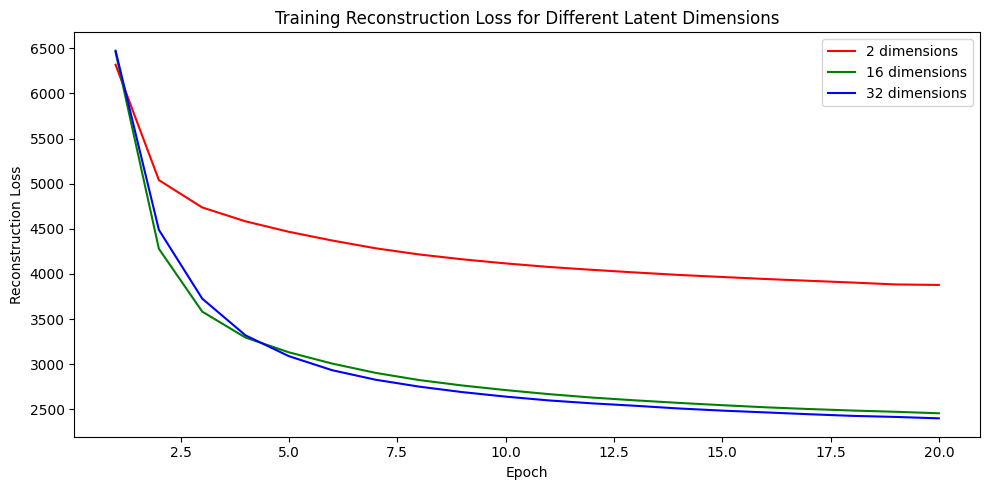

In [17]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), recon_2,  label='2 dimensions',  color='red')
plt.plot(range(1, EPOCHS+1), recon_16, label='16 dimensions', color='green')
plt.plot(range(1, EPOCHS+1), recon_32, label='32 dimensions', color='blue')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Training Reconstruction Loss for Different Latent Dimensions')
plt.legend()
plt.tight_layout()
plt.show()

Reconstruction and denoising errors for all 10,000 test images are shown for each latent dimension. The same noise is applied to every model.

In [21]:
models = {2: vae_2, 16: vae_16, 32: vae_32}
results = {}

print(f"{'Latent dim':>10}  {'Compression':>12}  {'Recon MSE':>10}  {'Noisy vs clean':>15}  {'Denoised vs clean':>18}")
print("-" * 75)
for dim, model in models.items():
    recon_mse = test_set_mse(model)
    noisy_mse, denoised_mse = test_set_denoise_mse(model)
    results[dim] = (recon_mse, noisy_mse, denoised_mse)
    print(f"{dim:>10}  {compression_ratio(dim):>9g} : 1  {recon_mse:>10.4f}  {noisy_mse:>15.4f}  {denoised_mse:>18.4f}")

Latent dim   Compression   Recon MSE   Noisy vs clean   Denoised vs clean
---------------------------------------------------------------------------
         2        392 : 1      0.0378           0.0467              0.0670
        16         49 : 1      0.0202           0.0467              0.0591
        32       24.5 : 1      0.0191           0.0467              0.0468


## Step 9: Comparing Images Across Latent Dimensions

The same 10 test images are reconstructed and denoised using VAEs with latent dimensions of 2, 16, and 32. This allows the outputs to be compared directly.

Average MSE over the 10 sample images (clean reconstruction)
   2 dimensions: 0.0396
  16 dimensions: 0.0202
  32 dimensions: 0.0212


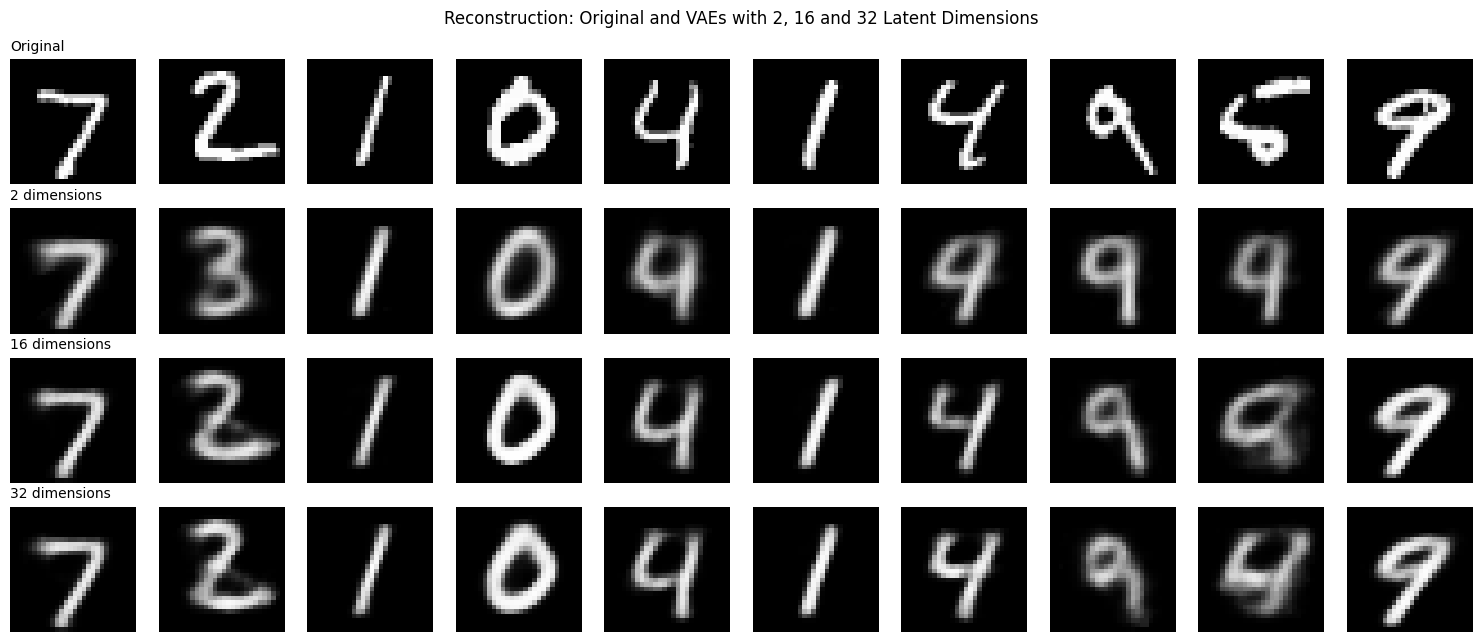

In [19]:
dims = [2, 16, 32]

# reconstruction of the clean images by each model
recon_images = {}
print("Average MSE over the 10 sample images (clean reconstruction)")
for d in dims:
    r = decode(models[d], encode(models[d], sample_images))
    recon_images[d] = r.cpu().view(-1, 28, 28).numpy()
    mse10 = ((r - sample_images.view(-1, 784)) ** 2).mean().item()
    print(f"  {d:>2} dimensions: {mse10:.4f}")

orig = sample_images.cpu().view(-1, 28, 28).numpy()
rows = [(orig, 'Original'),
        (recon_images[2],  '2 dimensions'),
        (recon_images[16], '16 dimensions'),
        (recon_images[32], '32 dimensions')]

plt.figure(figsize=(15, 6.5))
for r, (imgs, name) in enumerate(rows):
    for i in range(NUM_TEST_IMAGES):
        plt.subplot(len(rows), NUM_TEST_IMAGES, r * NUM_TEST_IMAGES + i + 1)
        plt.imshow(imgs[i], cmap='gray', vmin=0, vmax=1)
        plt.axis('off')
        if i == 0:
            plt.title(name, fontsize=10, loc='left')

plt.suptitle('Reconstruction: Original and VAEs with 2, 16 and 32 Latent Dimensions')
plt.tight_layout()
plt.show()

Average MSE over the 10 sample images (denoised vs clean)
   2 dimensions: 0.0773
  16 dimensions: 0.0623
  32 dimensions: 0.0518


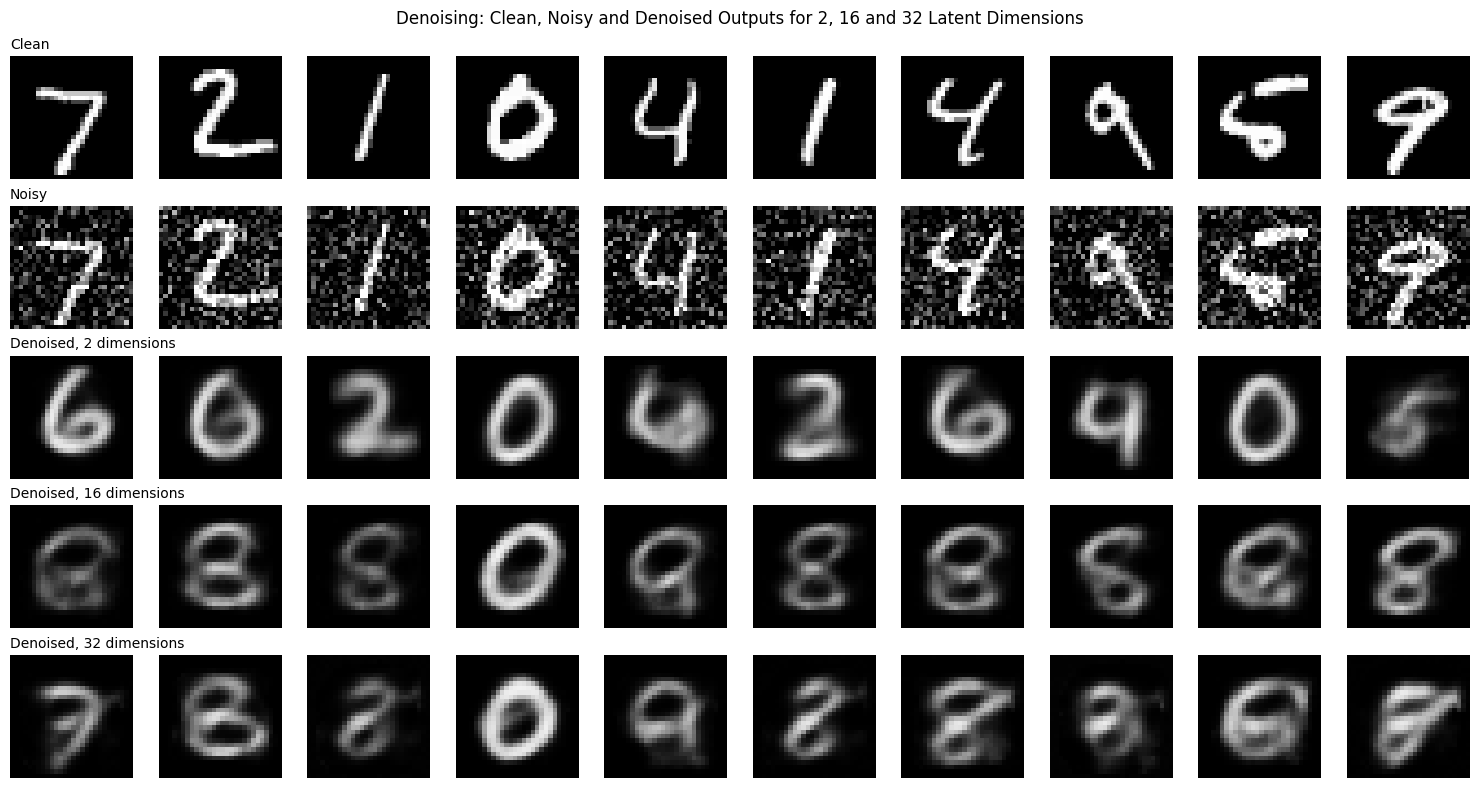

In [20]:
# denoising of the same noisy images by each model
denoised_images = {}
print("Average MSE over the 10 sample images (denoised vs clean)")
for d in dims:
    out = decode(models[d], encode(models[d], noisy_sample))
    denoised_images[d] = out.cpu().view(-1, 28, 28).numpy()
    mse10 = ((out - sample_images.view(-1, 784)) ** 2).mean().item()
    print(f"  {d:>2} dimensions: {mse10:.4f}")

noisy_np = noisy_sample.cpu().view(-1, 28, 28).numpy()
rows = [(orig, 'Clean'),
        (noisy_np, 'Noisy'),
        (denoised_images[2],  'Denoised, 2 dimensions'),
        (denoised_images[16], 'Denoised, 16 dimensions'),
        (denoised_images[32], 'Denoised, 32 dimensions')]

plt.figure(figsize=(15, 8))
for r, (imgs, name) in enumerate(rows):
    for i in range(NUM_TEST_IMAGES):
        plt.subplot(len(rows), NUM_TEST_IMAGES, r * NUM_TEST_IMAGES + i + 1)
        plt.imshow(imgs[i], cmap='gray', vmin=0, vmax=1)
        plt.axis('off')
        if i == 0:
            plt.title(name, fontsize=10, loc='left')

plt.suptitle('Denoising: Clean, Noisy and Denoised Outputs for 2, 16 and 32 Latent Dimensions')
plt.tight_layout()
plt.show()

## Step 10: Results Table

All reported errors represent the mean squared error per pixel across the 10,000 MNIST test images, with pixel values ranging from 0 to 1. Gaussian noise with a standard deviation of 0.3, clipped to [0, 1], was used for denoising. For this noise level, the noisy image itself has an error of 0.0467 relative to the clean image; therefore, a denoised error below 0.0467 would indicate an improvement.

| Latent dimension | Compression ratio | Reconstruction error (MSE) | Reconstruction quality | Denoising error (MSE) | Denoising observations |
|---|---|---|---|---|---|
| 2 | 392 : 1 | 0.0378 | Blurry. 4 of the 10 sample digits became different digits (2 became 3, both 4s and the 5 became 9). | 0.0670 | The output is smooth and clean-looking, but it is usually the wrong digit (the 7 and 2 became 6). The error is higher than that of the noisy input. |
| 16 | 49 : 1 | 0.0202 | Considerably sharper. 9 of the 10 sample digits are correct, with only the 5 being incorrect. | 0.0591 | The outputs are dim and smeared, with many becoming shapes similar to 8s. Only the 0 was clearly preserved. The error remains higher than that of the noisy input. |
| 32 | 24.5 : 1 | 0.0191 | Nearly the same as 16 dimensions. The improvement is very small, and some images appear blurrier. | 0.0468 | Some forms are partially preserved (7 and 0), but smudges and many 8-like blobs remain. The error is approximately equal to the noisy input rather than being better. |

The compression ratio is based on the number of values, calculated as 784 divided by the latent size. When measured in bits, the ratio is smaller because pixels use 8-bit values while latent values use 32-bit floats: 98 : 1, 12.25 : 1, and 6.125 : 1 for latent dimensions of 2, 16, and 32, respectively.

## Written Explanation

**Part A: Compression.** A MNIST image contains 784 values. With a 2-dimensional latent code, only 2 values are retained, giving a compression ratio of 392 : 1. For latent dimensions of 16 and 32, the ratios are 49 : 1 and 24.5 : 1. This is lossy compression because the decoder can reconstruct only an approximation of the original image.

**Part B: Reconstruction.** For the 2-dimensional model, the average error was 0.0378 and the reconstructed images were blurry. Four of the ten sample digits were reconstructed as different digits; for instance, the 2 resembled a 3 and the 4s resembled 9s. The MSE alone does not always reveal this difference clearly. The 4 that was reconstructed as a 9 had a lower error (0.026) than a correctly reconstructed 9 (0.057). This shows that a blurry but incorrect digit can still produce a relatively low pixel error.

**Part C: Denoising.** The noisy images were processed through the 2-dimensional VAE. Although the outputs appeared smooth and largely free of visible noise, most were reconstructed as the wrong digit. The error compared with the clean image (0.0670) was greater than the error of the noisy input itself (0.0467). Therefore, this VAE did not perform denoising effectively. One possible reason is that the model was trained only on clean images, meaning its encoder did not learn representations from noisy inputs.

**Part D: Changing the latent dimension.** Increasing the latent dimension from 2 to 16 nearly reduced the reconstruction error by half, from 0.0378 to 0.0202, while most digits retained their identity. Increasing it again from 16 to 32 produced only a minor improvement, reaching 0.0191. This should not be considered a definite improvement because each model was trained only once. Using more latent dimensions also reduces the compression ratio.

For denoising, increasing the latent dimension lowered the error from 0.0670 to 0.0591 and then to 0.0468, but it did not solve the underlying issue. At 16 dimensions, many outputs became 8-like shapes, while at 32 dimensions only some digits were partially preserved. Even with 32 dimensions, the error was approximately the same as that of the noisy input. Therefore, increasing the latent dimension significantly improves reconstruction, but it does not turn a VAE trained only on clean images into an effective denoising model.

**Limitations.** Each model was trained only once, and the experiment used a single noise level of 0.3. The visualizations containing 10 images represent only a small sample, so the results table is based on all 10,000 test images.